# Prediction of unemployment in Vienna districts using tourism and demographic data

## What is it about?
The aim of the experiment is to predict unemployment levels in the districts of Vienna by using tourism (overnight stays) and population data. As tourism is an important economic sector, it can influence employment levels in areas with higher visitor activity. By applying machine learning techniques to open government data, the experiment aims to determine if overnight stays and population are useful predictors for unemployment levels.


## Used datasets
The experiment uses two datasets from the Austrian Open Government Data portal:

### 1) Unemployed Persons Since 2002 - Districts of Vienna
(Stadt Wien - Wirtschaft und Finanzen, *Arbeitslos gemeldete Personen im Alter 15-64 Jahre nach Geschlecht (absolut und pro 1.000 EinwohnerInnen) im Jahresdurchschnitt seit 2002 - Bezirke Wien*, Open Government Data Austria, Dataset ID: 9462d680-ede9-40b9-8102-b9baebaa4fbb. Available at: https://www.data.gv.at/katalog/dataset/9462d680-ede9-40b9-8102-b9baebaa4fbb, 2025)

**Features:**
- `NUTS`: statistical region of Austria (always "AT13" for Vienna)
- `DISTRICT_CODE`: municipality code
- `SUB_DISTRICT_CODE`: census district code (same as municipality code in the granularity of this dataset)
- `REF_YEAR`: reference year
- `REF_DATE`: reference date
- `SEX`: 0 = total, 1 = men, 2 = women
- `UEP_VALUE`: average number of unemployed persons (age 15-64)
- `UEP_DENSITY`: unemployed persons per 1,000 inhabitants

### 2) Guest Overnight Stays Since 2002 - Districts of Vienna
(Stadt Wien - Wirtschaft und Finanzen, *Gästeübernachtungen (absolut und pro 1.000 EinwohnerInnen) seit 2002 - Bezirke Wien*, Open Government Data Austria, Dataset ID: ae4ebf87-9f46-4f05-9e3d-dbff002b216d. Available at: https://www.data.gv.at/katalog/datasets/ae4ebf87-9f46-4f05-9e3d-dbff002b216d, 2025)

**Features:**
- `NUTS`: statistical region of Austria (always "AT13" for Vienna)
- `DISTRICT_CODE`: municipality code
- `SUB_DISTRICT_CODE`: census district code (same as municipality code in the granularity of this dataset)
- `REF_YEAR`: reference year
- `REF_DATE`: reference date
- `TOU_VALUE`: total guest overnight stays
- `TOU_DENSITY`: overnight stays per 1,000 inhabitants
- `POP_AVE`: average population

-------
# Imports

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import joblib
import yaml
from dbrepo_client import create_client

In [14]:
# Load configuration
config_path = os.path.join("..", "config", "config_general.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

version = config['version']
data_path = config['paths']['data']
outputs_path = config['paths']['outputs']
figures_path = config['paths']['figures']
models_path = config['paths']['models']

# Create output directories if they don't exist
os.makedirs(outputs_path, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

-----
# Data Import

In [15]:
# df_tourism = pd.read_csv(
#     os.path.join(data_path, f"vienna_tourism_since_2002_raw_{version}.csv"),
#     sep=";",
#     skiprows=1,
#     decimal=",",
#     thousands="."
# ).dropna(axis=1, how="all")

# df_unemployment = pd.read_csv(
#     os.path.join(data_path, f"vienna_unemployment_since_2002_raw_{version}.csv"),
#     sep=";",
#     skiprows=1,
#     decimal=",",
#     thousands="."
# ).dropna(axis=1, how="all")

-----
# Pre-Processing

In [16]:
# display(df_tourism.head())

In [17]:
# display(df_unemployment.head())

In [18]:
# print("Tourism data NaN count per column:")
# print(df_tourism.isnull().sum())
# print("\nUnemployment data NaN count per column:")
# print(df_unemployment.isnull().sum())

In [19]:
# # select only the relevant columns for the analysis
# df_unemployment_small = df_unemployment[
#     ["DISTRICT_CODE", "REF_YEAR", "SEX", "UEP_VALUE", "UEP_DENSITY"]
# ]

# df_tourism_small = df_tourism[
#     ["DISTRICT_CODE", "REF_YEAR", "TOU_VALUE", "TOU_DENSITY", "POP_AVE"]
# ]

# # select only SEX = 0 which is the total (exclude SEX = 1 (male) and SEX = 2 (female))
# df_unemployment_small = df_unemployment_small[df_unemployment_small["SEX"] == 0]

# # exclude district 90000 which is the total for all districts
# df_unemployment_small = df_unemployment_small[df_unemployment_small["DISTRICT_CODE"] != 90000]
# df_tourism_small = df_tourism_small[df_tourism_small["DISTRICT_CODE"] != 90000]

# df_merged = pd.merge(
#     df_unemployment_small,
#     df_tourism_small,
#     on=["DISTRICT_CODE", "REF_YEAR"],
#     how="inner"
# )

# display(df_merged.head())

In [20]:
# ============================================
# DATA IMPORT - Using DBRepo API
# ============================================

print("Connecting to DBRepo...")
client = create_client()

print("Loading data from DBRepo views...")

# Load pre-split data directly from views (data already cleaned)
df_train_api = client.get_train_data()
df_val_api = client.get_validation_data()
df_test_api = client.get_test_data()

# Rename columns to match original notebook expectations
column_rename = {
    'district_code': 'DISTRICT_CODE',
    'ref_year': 'REF_YEAR',
    'uep_value': 'UEP_VALUE',
    'uep_density': 'UEP_DENSITY',
    'tou_value': 'TOU_VALUE',
    'tou_density': 'TOU_DENSITY',
    'population_avg': 'POP_AVE'
}

df_train = df_train_api.rename(columns=column_rename)
df_val = df_val_api.rename(columns=column_rename)
df_test = df_test_api.rename(columns=column_rename)

print(f"Train set: {len(df_train)} samples")
print(f"Validation set: {len(df_val)} samples")
print(f"Test set: {len(df_test)} samples")

# Combine for EDA (original notebook uses df_merged)
df_merged = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"Total merged data: {len(df_merged)} samples")

print("\n✅ Data loaded successfully from DBRepo API!")
print("Note: The views already handle filtering for gender='Both', excluding district 90000, and excluding COVID years 2020/2021.")

Connecting to DBRepo...
Loading data from DBRepo views...
Train set: 322 samples
Validation set: 69 samples
Test set: 69 samples
Total merged data: 460 samples

✅ Data loaded successfully from DBRepo API!
Note: The views already handle filtering for gender='Both', excluding district 90000, and excluding COVID years 2020/2021.


-----
# EDA

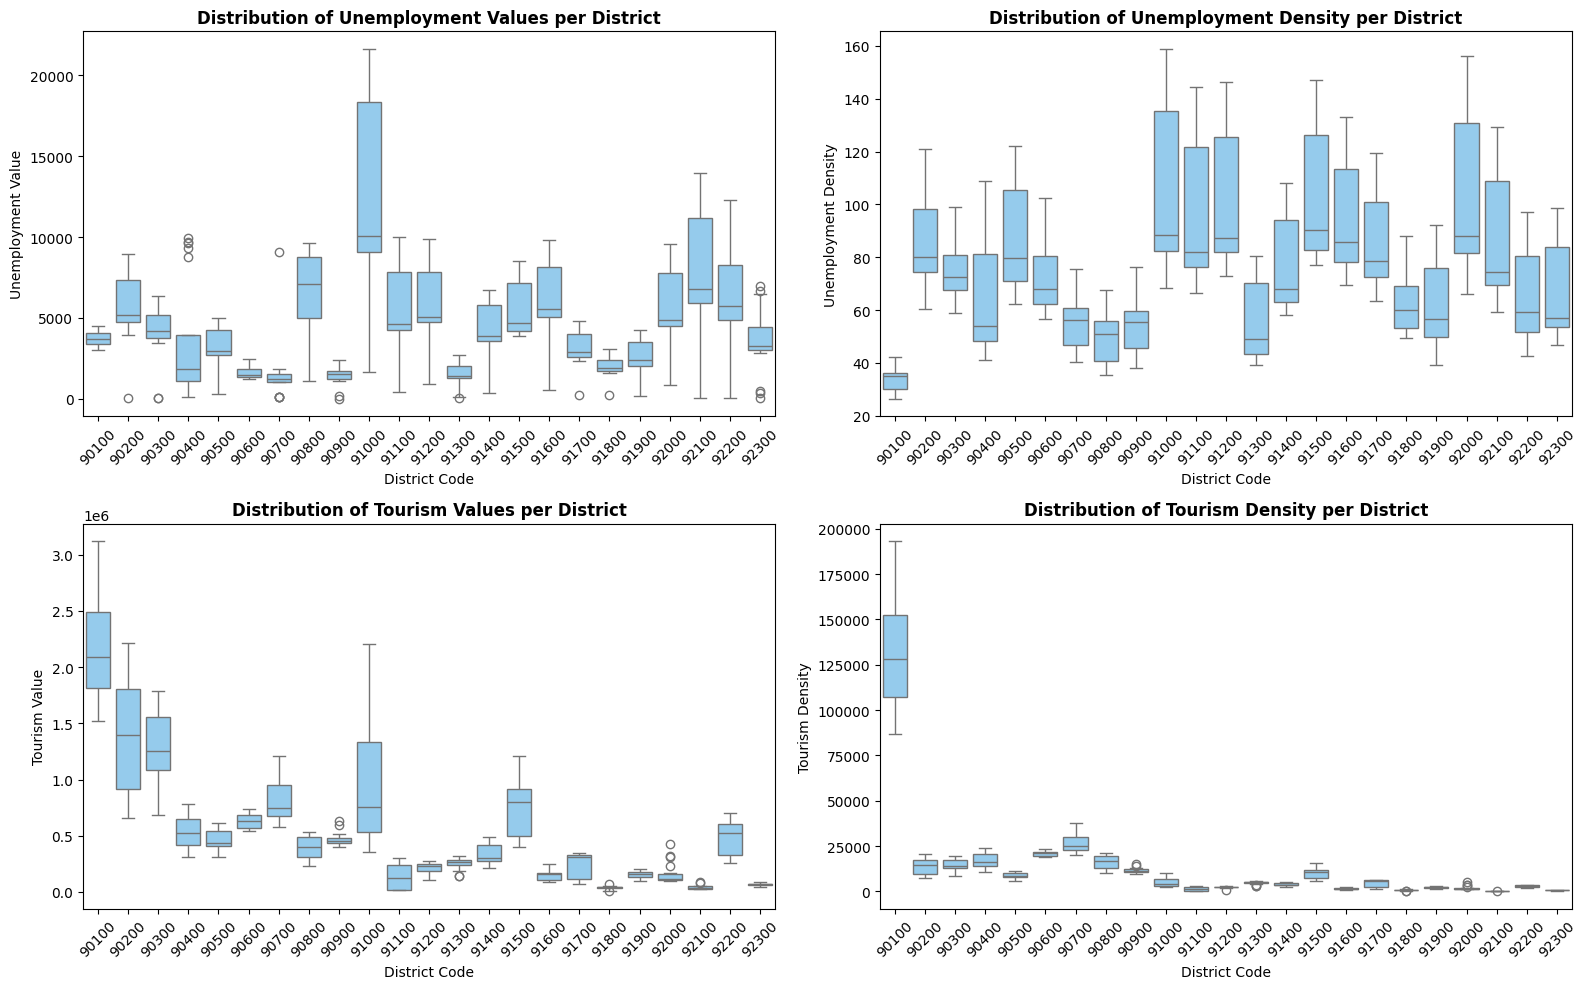

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Unemployment value by district
sns.boxplot(data=df_merged, x='DISTRICT_CODE', y='UEP_VALUE', ax=axes[0, 0], color="lightskyblue")
axes[0, 0].set_title('Distribution of Unemployment Values per District', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('District Code')
axes[0, 0].set_ylabel('Unemployment Value')
axes[0, 0].tick_params(axis='x', rotation=45)

# Unemployment density by district
sns.boxplot(data=df_merged, x='DISTRICT_CODE', y='UEP_DENSITY', ax=axes[0, 1], color="lightskyblue")
axes[0, 1].set_title('Distribution of Unemployment Density per District', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('District Code')
axes[0, 1].set_ylabel('Unemployment Density')
axes[0, 1].tick_params(axis='x', rotation=45)

# Tourism value by district
sns.boxplot(data=df_merged, x='DISTRICT_CODE', y='TOU_VALUE', ax=axes[1, 0], color="lightskyblue")
axes[1, 0].set_title('Distribution of Tourism Values per District', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('District Code')
axes[1, 0].set_ylabel('Tourism Value')
axes[1, 0].tick_params(axis='x', rotation=45)

# Tourism density by district
sns.boxplot(data=df_merged, x='DISTRICT_CODE', y='TOU_DENSITY', ax=axes[1, 1], color="lightskyblue")
axes[1, 1].set_title('Distribution of Tourism Density per District', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('District Code')
axes[1, 1].set_ylabel('Tourism Density')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(figures_path, f"fig_unemployment_tourism_per_district_{version}.png"), dpi=300, bbox_inches='tight')
plt.show()

The boxplots above show the distribution of unemployment and tourism values across all districts. We can observe that outer districts (10th, 21st, 22nd) generally show higher unemployment values while also having lower tourism values (overnight stays) compared to inner districts (1st, 4th, 6th). This trend can also be seen on the density per district chart, although it is not as prominent here. This is likely due to the fact, that the number of people living in outer districts is larger.

The first district has the most tourist activity, and also has the lowest unemployment. The 10th district also shows higher tourism values, but has one of the highest unemployment values.

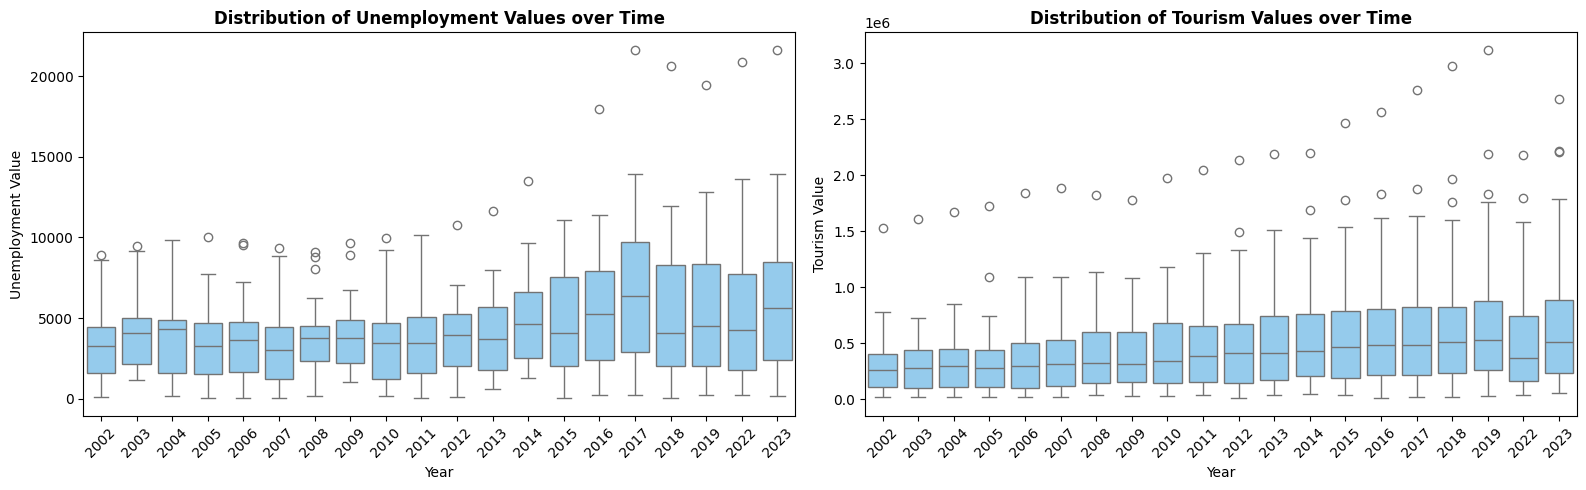

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Unemployment value by year
sns.boxplot(data=df_merged, x='REF_YEAR', y='UEP_VALUE', ax=axes[0], color="lightskyblue")
axes[0].set_title('Distribution of Unemployment Values over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Unemployment Value')
axes[0].tick_params(axis='x', rotation=45)

# Tourism value by year
sns.boxplot(data=df_merged, x='REF_YEAR', y='TOU_VALUE', ax=axes[1], color="lightskyblue")
axes[1].set_title('Distribution of Tourism Values over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tourism Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(figures_path, f"fig_unemployment_tourism_over_time_{version}.png"), dpi=300, bbox_inches='tight')
plt.show()

The boxplots above show the distribution of unemployment and tourism values over time. Generally, unemployment as well as tourism seems to be steadily rising over time. In the years 2020 and 2021, we can see a sharp decline in tourism activity, which is due to the COVID-19 pandemic.

-----
# Outlier Handling

When looking at the boxplots of tourism values over time, we can see a heavy decline in tourism values for the years 2020 and 2021, which are due to the COVID-19 pandemic. These years are considered outliers and rather add noise than signal to the data, so we will remove them to improve the performance of the model.

In [23]:
# df_merged_cleaned = df_merged[~df_merged['REF_YEAR'].isin([2020, 2021])].copy()

# print(f"Original dataset size: {len(df_merged)}")
# print(f"Cleaned dataset size: {len(df_merged_cleaned)}")
# print(f"Removed {len(df_merged) - len(df_merged_cleaned)} rows ({(len(df_merged) - len(df_merged_cleaned))/len(df_merged)*100:.1f}%)")

-----
# Categorical Feature Handling

In [24]:
# one-hot encode the district codes
# Note: Use df_merged (not df_merged_cleaned) since views already exclude COVID years
df_encoded = df_merged.copy()

district_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
district_encoder.fit(df_encoded[['DISTRICT_CODE']])

district_encoded = pd.DataFrame(
    district_encoder.transform(df_encoded[['DISTRICT_CODE']]),
    columns=[f'DISTRICT_{int(code)}' for code in district_encoder.categories_[0]],
    index=df_encoded.index
)

df_encoded = pd.concat([df_encoded, district_encoded], axis=1)
df_encoded.drop(columns=['DISTRICT_CODE'], inplace=True)
print(df_encoded.columns)

Index(['POP_AVE', 'reference_date', 'TOU_DENSITY', 'TOU_VALUE', 'UEP_DENSITY',
       'UEP_VALUE', 'REF_YEAR', 'DISTRICT_90100', 'DISTRICT_90200',
       'DISTRICT_90300', 'DISTRICT_90400', 'DISTRICT_90500', 'DISTRICT_90600',
       'DISTRICT_90700', 'DISTRICT_90800', 'DISTRICT_90900', 'DISTRICT_91000',
       'DISTRICT_91100', 'DISTRICT_91200', 'DISTRICT_91300', 'DISTRICT_91400',
       'DISTRICT_91500', 'DISTRICT_91600', 'DISTRICT_91700', 'DISTRICT_91800',
       'DISTRICT_91900', 'DISTRICT_92000', 'DISTRICT_92100', 'DISTRICT_92200',
       'DISTRICT_92300'],
      dtype='object')


In [25]:
# Export processed dataset
processed_data_path = os.path.join(data_path, f"vienna_unemployment_tourism_processed_{version}.csv")
df_encoded.to_csv(processed_data_path, index=False)

-----
# Train, Validation, Test Split

To prevent data leakage from the future into training data, we split our time series data into the following segments by years:

Training: 2002 - 2015 <br>
Validation: 2016 - 2018 <br>
Test: 2019+ (without 2020 and 2021)

In [26]:
# df_train = df_encoded[df_encoded['REF_YEAR'] <= 2015].copy()
# df_val = df_encoded[(df_encoded['REF_YEAR'] >= 2016) & (df_encoded['REF_YEAR'] <= 2018)].copy()
# df_test = df_encoded[df_encoded['REF_YEAR'] >= 2019].copy()

# print(f"Train set: {len(df_train)} samples ({df_train['REF_YEAR'].min()} - {df_train['REF_YEAR'].max()})")
# print(f"Validation set: {len(df_val)} samples ({df_val['REF_YEAR'].min()} - {df_val['REF_YEAR'].max()})")
# print(f"Test set: {len(df_test)} samples ({df_test['REF_YEAR'].min()} - {df_test['REF_YEAR'].max()})")

-----
# Modeling

In [27]:
numeric_features = ['TOU_VALUE', 'POP_AVE']
categorical_features = [col for col in df_train.columns if col.startswith('DISTRICT_')]
all_feature_cols = numeric_features + categorical_features
target_col = 'UEP_VALUE'

X_train = df_train[all_feature_cols].values
y_train = df_train[target_col].values
X_val = df_val[all_feature_cols].values
y_val = df_val[target_col].values

tuned_models = {}

# -----------------------------------------------
# Linear Regression
# -----------------------------------------------
print("Training Linear Regression...")
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_val_pred = lr_model.predict(X_val)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))

tuned_models['Linear Regression'] = {
    'model': lr_model,
    'best_params': {},
    'val_rmse': lr_val_rmse
}
print(f"  Validation RMSE: {lr_val_rmse:.4f}")

# -----------------------------------------------
# Random Forest
# -----------------------------------------------
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

best_rf_rmse = np.inf
best_rf_params = None
best_rf_model = None

# grid search to find the best hyperparameters for random forest
for n_est in rf_param_grid['n_estimators']:
    for depth in rf_param_grid['max_depth']:
        for min_split in rf_param_grid['min_samples_split']:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(
                    n_estimators=n_est,
                    max_depth=depth,
                    min_samples_split=min_split,
                    random_state=42,
                    n_jobs=-1
                ))
            ])
            model.fit(X_train, y_train)
            rf_val_pred = model.predict(X_val)
            rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
            
            if rf_val_rmse < best_rf_rmse:
                best_rf_rmse = rf_val_rmse
                best_rf_params = {
                    'n_estimators': n_est,
                    'max_depth': depth,
                    'min_samples_split': min_split
                }
                best_rf_model = model

tuned_models['Random Forest'] = {
    'model': best_rf_model,
    'best_params': best_rf_params,
    'val_rmse': best_rf_rmse
}
print(f"  Best params: {best_rf_params}")
print(f"  Validation RMSE: {best_rf_rmse:.4f}")

print("\n-------------------------------------------------------------------------------")
best_model_name = min(tuned_models.keys(), key=lambda x: tuned_models[x]['val_rmse'])
print(f"Best model (by Validation RMSE): {best_model_name}")
print(f"Best Validation RMSE: {tuned_models[best_model_name]['val_rmse']:.4f}")

Training Linear Regression...
  Validation RMSE: 3788.1879

Tuning Random Forest...
  Best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
  Validation RMSE: 3574.5065

-------------------------------------------------------------------------------
Best model (by Validation RMSE): Random Forest
Best Validation RMSE: 3574.5065


-----
# Evaluation

In [28]:
X_test = df_test[all_feature_cols].values
y_test = df_test[target_col].values

# combine train and validation data for final training on all non-test data
X_train_combined = np.concatenate([X_train, X_val])
y_train_combined = np.concatenate([y_train, y_val])

evaluation_results = {}

for name, model_info in tuned_models.items():
    model = model_info['model']
    val_rmse = model_info['val_rmse']
    
    # retrain on combined training and validation data
    model.fit(X_train_combined, y_train_combined)
    
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    evaluation_results[name] = {
        'val_rmse': val_rmse,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'y_test_pred': y_test_pred
    }
    
    print(f"\n{name}:")
    print(f"  Validation RMSE (best hyperparameters): {val_rmse:.4f}")
    print(f"  Test R^2: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Validation RMSE: {val_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")

print("\n-------------------------------------------------------------------------------")
best_model_name = min(evaluation_results.keys(), key=lambda x: evaluation_results[x]['test_rmse'])
print(f"Best model (by Test RMSE): {best_model_name}")
print(f"Best Test RMSE: {evaluation_results[best_model_name]['test_rmse']:.4f}")
print(f"Best Hyperparameters: {tuned_models[best_model_name]['best_params']}")


Linear Regression:
  Validation RMSE (best hyperparameters): 3788.1879
  Test R^2: 0.4457
  Test RMSE: 3485.4607
  Validation RMSE: 3788.1879
  Test MAE: 2505.1559

Random Forest:
  Validation RMSE (best hyperparameters): 3574.5065
  Test R^2: 0.4822
  Test RMSE: 3368.6597
  Validation RMSE: 3574.5065
  Test MAE: 1775.3742

-------------------------------------------------------------------------------
Best model (by Test RMSE): Random Forest
Best Test RMSE: 3368.6597
Best Hyperparameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}


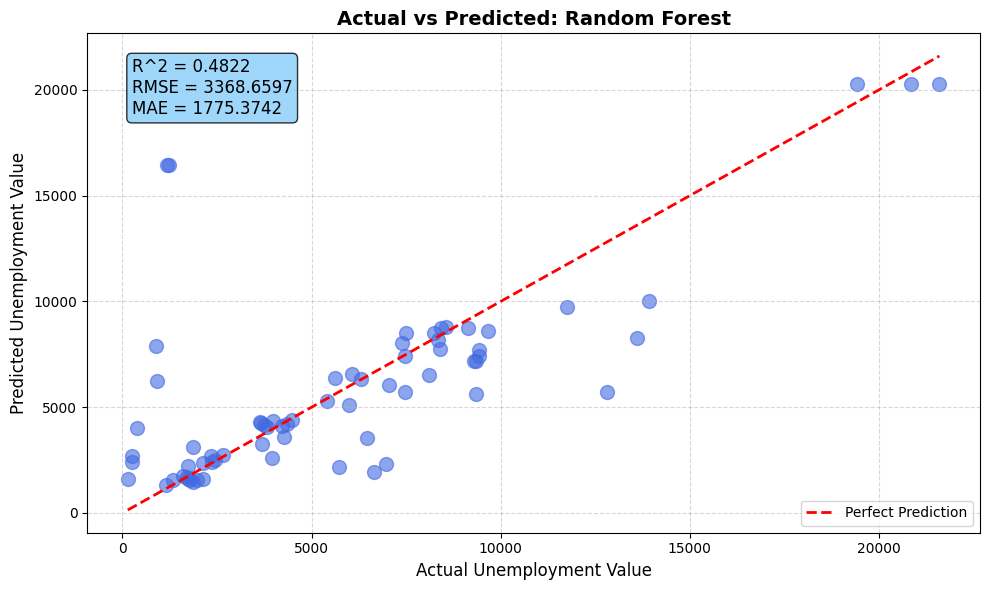

In [29]:
best_model = evaluation_results[best_model_name]
best_pred = best_model['y_test_pred']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, best_pred, alpha=0.6, s=100, color='royalblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, label='Perfect Prediction', color="red")
ax.set_xlabel('Actual Unemployment Value', fontsize=12)
ax.set_ylabel('Predicted Unemployment Value', fontsize=12)
ax.set_title(f'Actual vs Predicted: {best_model_name}', fontsize=14, fontweight='bold')
ax.text(0.05, 0.95, f'R^2 = {best_model["test_r2"]:.4f}\nRMSE = {best_model["test_rmse"]:.4f}\nMAE = {best_model["test_mae"]:.4f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightskyblue', alpha=0.8))

ax.legend()
ax.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(figures_path, f"fig_unemployment_actual_predicted_{version}.png"), dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Export the best model
model_to_save = tuned_models[best_model_name]['model']
model_path = os.path.join(models_path, f"model_{best_model_name.lower().replace(' ', '_')}_{version}.pkl")
joblib.dump(model_to_save, model_path)

['../outputs/models\\model_random_forest_v1.0.pkl']

The best model that we tried achieved an RMSE of ~1163 and a MAE of ~676. By plotting the actual observations against our predicted unemployment values, we can see that the model is quite accurate for lower unemployment values, but becomes less accurate for districts with unemployment values above roughly 5000. This suggests that overnight stays and population capture the general trend across most districts, but are insufficient to fully explain higher unemployment levels. Overall, the results indicate that tourism activity and population size are useful predictors of unemployment levels across Vienna's districts.